# IS310 Final Project — Underground Spotify Songs

**Author:** Raymond Zhang  
**Date:** May 2026  
**Dataset Source:** Kaggle — Spotify Tracks Dataset  
**Source URL:** https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset  
**Output:** `scaledDataset.csv` — ~52,651 songs, popularity 5–60, English-language genres

## 1. Imports and Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42

pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid')

print("Libraries loaded.")

Libraries loaded.


## 2. Load Full Dataset

Loading the full 114,000-song Kaggle dataset one directory above this notebook.

In [2]:
df_full = pd.read_csv('../dataset 2.csv', index_col=0)

print(f"Shape: {df_full.shape}")
print(f"\nColumns:\n{df_full.columns.tolist()}")
print(f"\nNull counts:\n{df_full.isnull().sum()}")
print(f"\nPopularity range: {df_full['popularity'].min()} – {df_full['popularity'].max()}")
print(f"Unique genres: {df_full['track_genre'].nunique()}")
df_full.head(3)

Shape: (114000, 20)

Columns:
['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Null counts:
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Popularity range: 0 – 100
Unique genres: 114


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


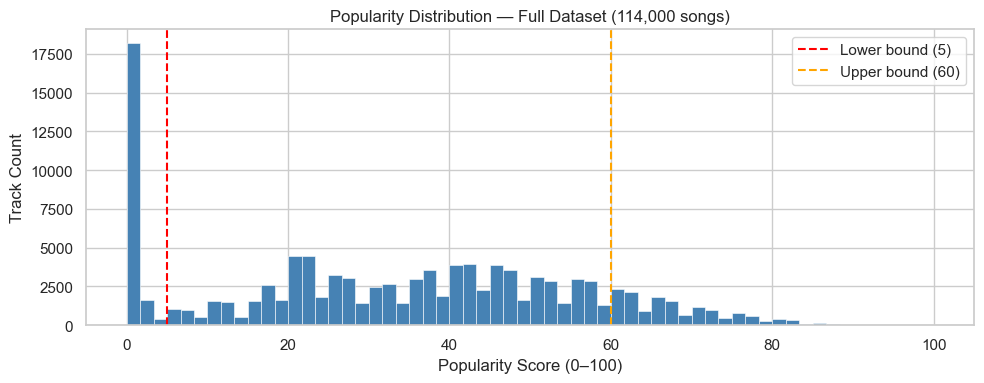

Songs with popularity = 0:    16,020
Songs with popularity 5–60:   80,260
Songs with popularity > 60:   13,570


In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_full['popularity'], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(5,  color='red',    linestyle='--', linewidth=1.5, label='Lower bound (5)')
ax.axvline(60, color='orange', linestyle='--', linewidth=1.5, label='Upper bound (60)')
ax.set_title('Popularity Distribution — Full Dataset (114,000 songs)')
ax.set_xlabel('Popularity Score (0–100)')
ax.set_ylabel('Track Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Songs with popularity = 0:    {(df_full['popularity'] == 0).sum():,}")
print(f"Songs with popularity 5–60:   {df_full['popularity'].between(5, 60).sum():,}")
print(f"Songs with popularity > 60:   {(df_full['popularity'] > 60).sum():,}")

## 3. Filtering — Building the Underground Pool

Three sequential filters:
1. **Popularity 5–60** — excludes songs with essentially no listeners (0–4) and mainstream hits (61+)
2. **English-language genre filter** — excludes genre tags that are predominantly non-English
3. **Deduplication** — the source dataset lists tracks multiple times under different genres; keep first occurrence per `track_id`

In [4]:
NON_ENGLISH_GENRES = {
    'k-pop', 'cantopop', 'mandopop', 'latin', 'latino', 'salsa',
    'turkish', 'samba', 'tango', 'mpb', 'pagode', 'sertanejo',
    'forro', 'romance', 'french', 'german', 'spanish', 'iranian',
    'j-pop', 'j-dance', 'j-idol', 'j-rock', 'malay',
    'reggaeton', 'brazil', 'swedish', 'indian', 'anime'
}

# step 1: popularity filter
df_pop = df_full[df_full['popularity'].between(5, 60)].copy()
print(f"After popularity filter (5–60):       {len(df_pop):>7,} rows")

# step 2: english-language genre filter
df_eng = df_pop[~df_pop['track_genre'].str.lower().isin(NON_ENGLISH_GENRES)].copy()
print(f"After English-genre filter:            {len(df_eng):>7,} rows")

# step 3:deduplicate on track_id
df_deduped = df_eng.drop_duplicates(subset='track_id', keep='first').copy()
print(f"After deduplication on track_id:       {len(df_deduped):>7,} rows")
print(f"\nThis filtered pool is the sampling frame for the final dataset.")

After popularity filter (5–60):        80,260 rows
After English-genre filter:             59,415 rows
After deduplication on track_id:        52,651 rows

This filtered pool is the sampling frame for the final dataset.


In [5]:
df_scaled = df_deduped.reset_index(drop=True).copy()

print(f"Scaled dataset: {df_scaled.shape[0]:,} rows × {df_scaled.shape[1]} columns")
print(f"Popularity range: {df_scaled['popularity'].min()} – {df_scaled['popularity'].max()}")

Scaled dataset: 52,651 rows × 20 columns
Popularity range: 5 – 60


## 4. EDA — Scaled Dataset

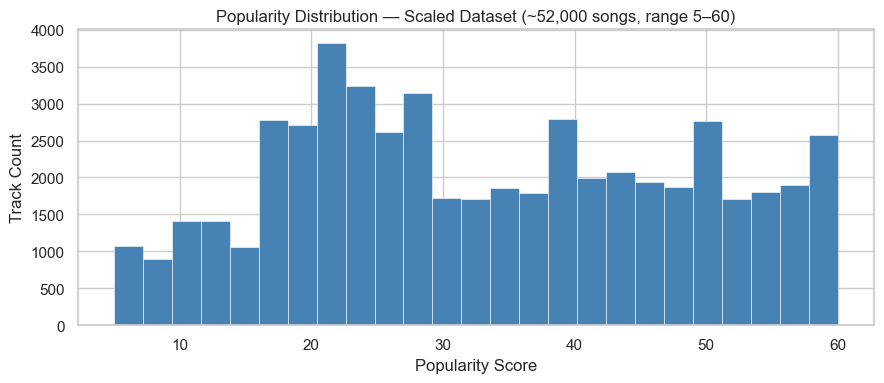

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_scaled['popularity'], bins=25, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_title('Popularity Distribution — Scaled Dataset (~52,000 songs, range 5–60)')
ax.set_xlabel('Popularity Score')
ax.set_ylabel('Track Count')
plt.tight_layout()
plt.show()

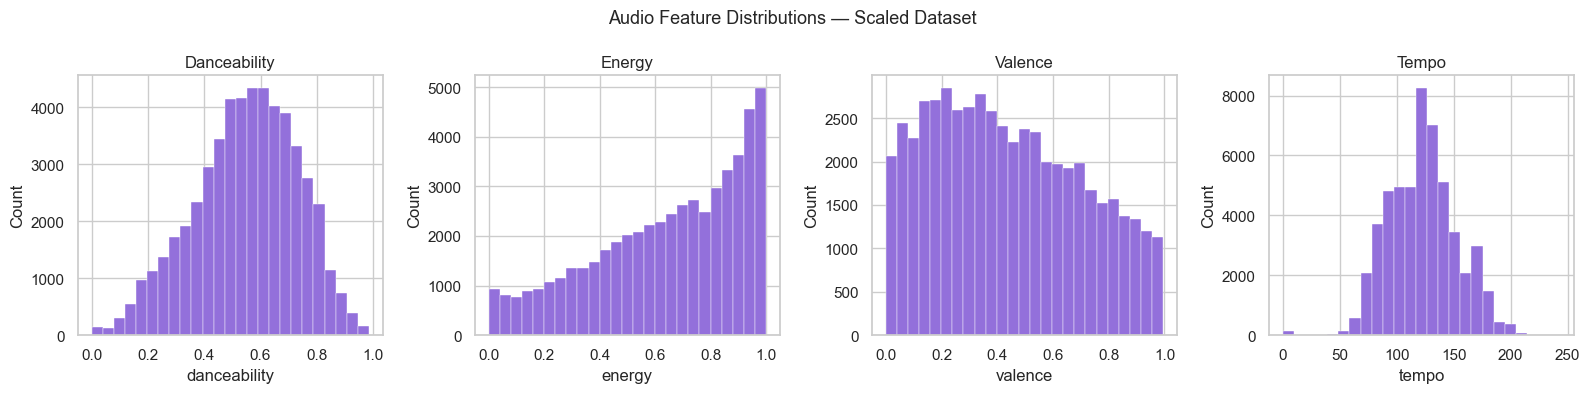

In [7]:
features = ['danceability', 'energy', 'valence', 'tempo']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, feat in zip(axes, features):
    ax.hist(df_scaled[feat], bins=25, color='mediumpurple', edgecolor='white', linewidth=0.3)
    ax.set_title(feat.capitalize())
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')

fig.suptitle('Audio Feature Distributions — Scaled Dataset', fontsize=13)
plt.tight_layout()
plt.show()

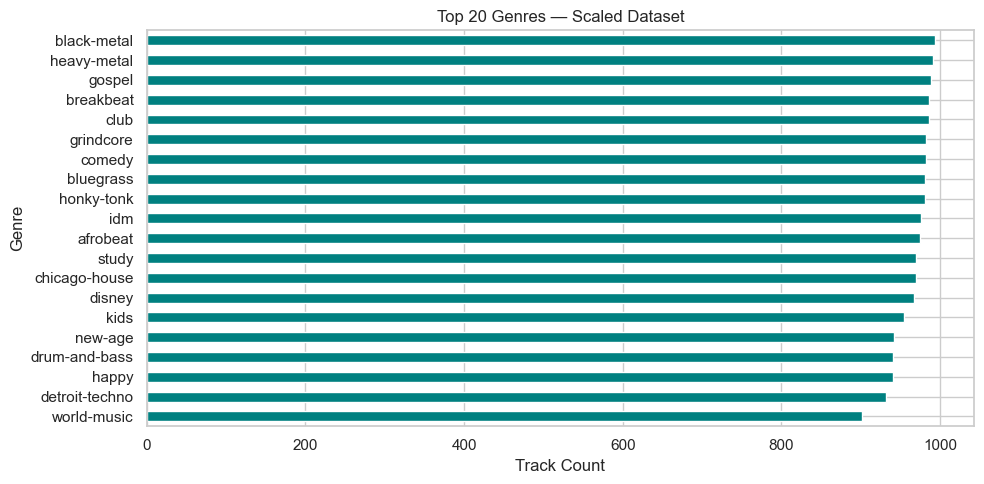

In [8]:
top_genres = df_scaled['track_genre'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 5))
top_genres.plot(kind='barh', ax=ax, color='teal', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 20 Genres — Scaled Dataset')
ax.set_xlabel('Track Count')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.show()

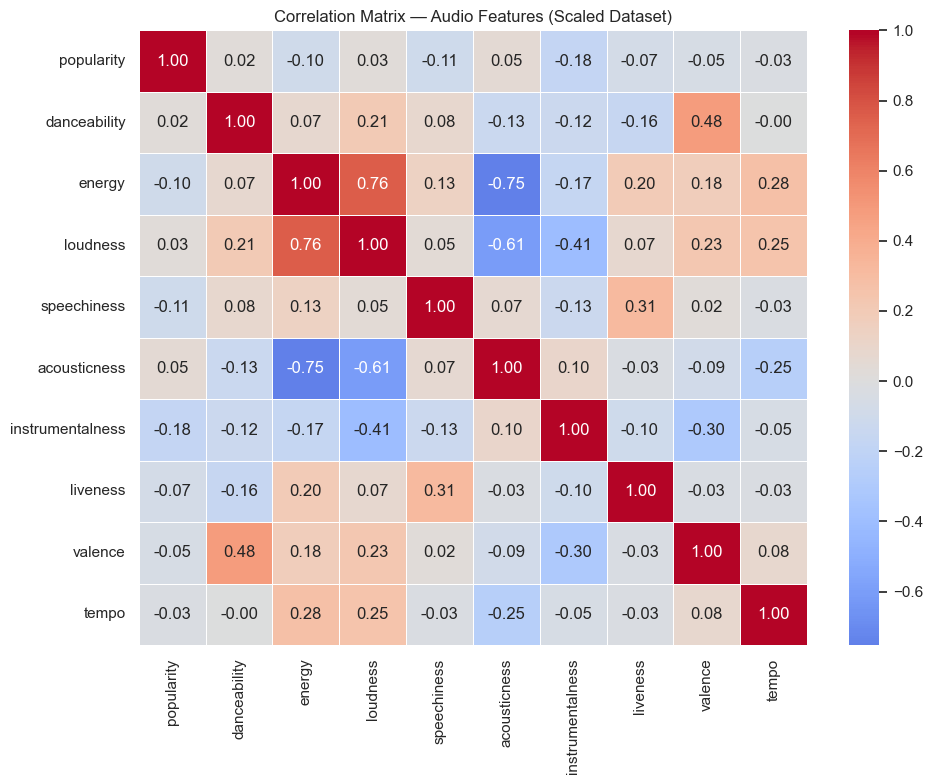

In [9]:
audio_cols = [
    'popularity', 'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo'
]

corr = df_scaled[audio_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax
)
ax.set_title('Correlation Matrix — Audio Features (Scaled Dataset)')
plt.tight_layout()
plt.show()

In [10]:
summary_cols = [
    'popularity', 'danceability', 'energy', 'valence',
    'tempo', 'acousticness', 'instrumentalness', 'speechiness'
]

print("=== Key Statistics — Scaled Dataset ===\n")
stats = df_scaled[summary_cols].agg(['mean', 'median', 'std', 'min', 'max'])
print(stats.round(3).to_string())

print(f"\nExplicit tracks:  {df_scaled['explicit'].sum()} ({df_scaled['explicit'].mean()*100:.1f}%)")
print(f"Unique genres:    {df_scaled['track_genre'].nunique()}")
print(f"Unique artists:   {df_scaled['artists'].nunique()}")

=== Key Statistics — Scaled Dataset ===

        popularity  danceability  energy  valence    tempo  acousticness  instrumentalness  speechiness
mean        33.359         0.549   0.645    0.438  122.885         0.301             0.238        0.093
median      32.000         0.561   0.695    0.409  123.612         0.117             0.001        0.050
std         14.783         0.183   0.269    0.266   30.134         0.345             0.360        0.130
min          5.000         0.000   0.000    0.000    0.000         0.000             0.000        0.000
max         60.000         0.985   1.000    0.995  243.372         0.996             1.000        0.965

Explicit tracks:  4307 (8.2%)
Unique genres:    85
Unique artists:   20186


## 5. Export Datasets

In [11]:
import os

out_path = 'scaledDataset.csv'
df_scaled.to_csv(out_path, index=False)
print(f"Saved scaledDataset.csv — {len(df_scaled):,} rows, {df_scaled.shape[1]} columns")
print(f"File size: {os.path.getsize(out_path) / 1024:.1f} KB")

Saved scaledDataset.csv — 52,651 rows, 20 columns
File size: 8795.4 KB
